In [5]:
import kagglehub

# качаем дата сет
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)


E:\Projects\Python\MashineLeaning\HomeWork1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Home\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [24]:
#  заполняем дата сет
import pandas as pd
#path='C:/Users/Home/.cache/kagglehub/datasets/dgomonov/new-york-city-airbnb-open-data/versions/3'
data = pd.read_csv(path+'/'+'AB_NYC_2019.csv')
# колонки в которых есть пропуски
data.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [26]:
import numpy as np
# добавление нового признака евклидова расстояния между районом и Manhattan
# Вычисляем координаты центра
manhattan_center_lat = data[data['neighbourhood_group'] == 'Manhattan']['latitude'].mean()
manhattan_center_lon = data[data['neighbourhood_group'] == 'Manhattan']['longitude'].mean()

# Создаём колонку с евклидовым расстоянием до центра Манхэттена sqrt((lat - lat_center)^2 + (lon - lon_center)^2)
data['distance_to_manhattan'] = np.sqrt(
    (data['latitude'] - manhattan_center_lat)**2 +
    (data['longitude'] - manhattan_center_lon)**2
)
data.info()

<class 'pandas.DataFrame'>
Index: 48656 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48656 non-null  str    
 1   neighbourhood                   48656 non-null  str    
 2   room_type                       48656 non-null  str    
 3   price                           48656 non-null  int64  
 4   minimum_nights                  48656 non-null  int64  
 5   number_of_reviews               48656 non-null  int64  
 6   calculated_host_listings_count  48656 non-null  int64  
 7   availability_365                48656 non-null  int64  
 8   price_neighbourhood             48656 non-null  float64
 9   price_room_type                 48656 non-null  float64
 10  price_neighbourhood_group       48656 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 4.5 MB


In [28]:
# удаляем ненужные колонки  (reviews_per_month так как в процентном соотношении много пропусков и есть number_of_reviews)
cols_to_drop = ['id', 'name', 'host_id', 'host_name', 'last_review','latitude','longitude','reviews_per_month']
data_clean = data.drop(cols_to_drop, axis=1)
# проверяем что осталось
data_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   room_type                       48895 non-null  str    
 3   price                           48895 non-null  int64  
 4   minimum_nights                  48895 non-null  int64  
 5   number_of_reviews               48895 non-null  int64  
 6   calculated_host_listings_count  48895 non-null  int64  
 7   availability_365                48895 non-null  int64  
 8   distance_to_manhattan           48895 non-null  float64
dtypes: float64(1), int64(5), str(3)
memory usage: 3.4 MB


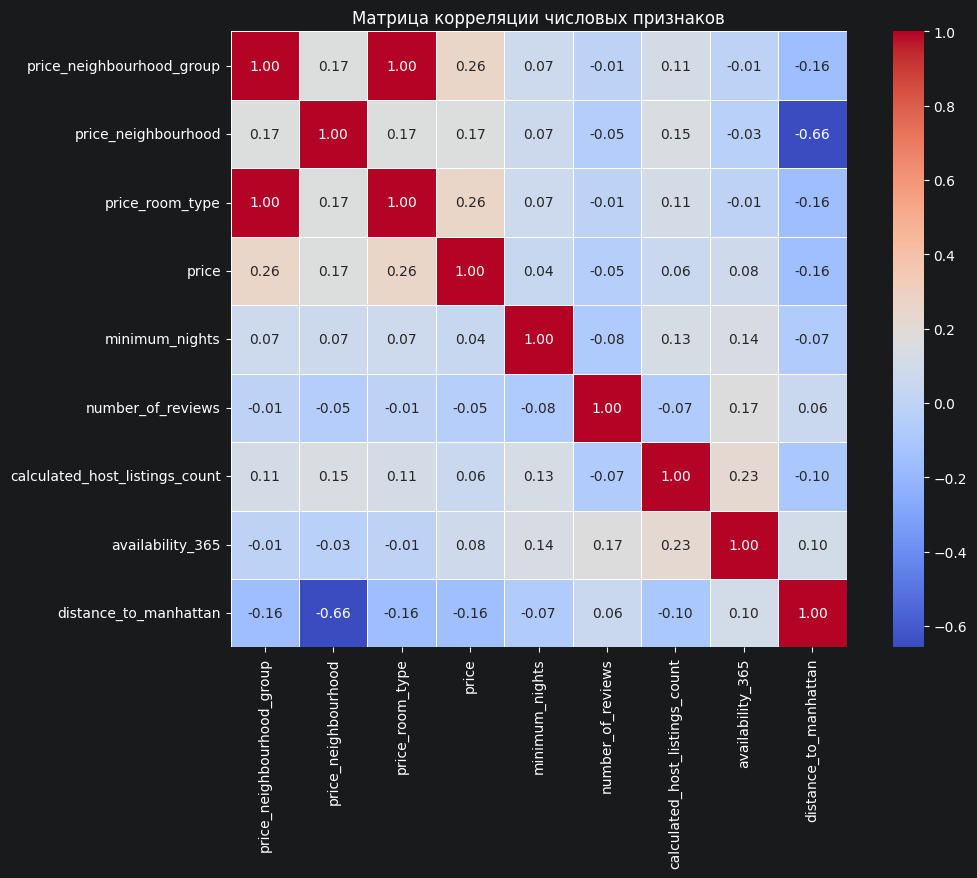

In [29]:
# матрица попарных корреляций признаков
import seaborn as sns
import matplotlib.pyplot as plt


# для категоральных признков создадим два поля по средней цене по этому признаку
data_clean['price_neighbourhood'] = data.groupby('neighbourhood_group')['price'].transform('mean')
data_clean['price_room_type'] = data.groupby('room_type')['price'].transform('mean')
data_clean['price_neighbourhood_group'] = data.groupby('room_type')['price'].transform('mean')

# поля для графика попарных корреляций
numeric_cols = ['price_neighbourhood_group', 'price_neighbourhood', 'price_room_type', 'price',
                'minimum_nights', 'number_of_reviews',
                'calculated_host_listings_count', 'availability_365','distance_to_manhattan']

# Тепловую карту корреляций
plt.figure(figsize=(12, 8))
corr_matrix = data_clean[numeric_cols].corr()
sns.heatmap(corr_matrix,
            annot=True,        # Показывать цифры
            fmt='.2f',         # Формат с 2 знаками
            cmap='coolwarm',   # Цветовая схема
            square=True,
            linewidths=0.5)
plt.title('Матрица корреляции числовых признаков')
plt.show()

# Если 1, то сильная прямая связь, если -1, то сильная обратная связь, если 0, то связи нет. Между price_neighbourhood и price_room_type сльная прямая связь. Между price_neighbourhood и availability_365 связи почти нет. distance_to_manhattan серьезно коррелирует в обртную сторону с price_neighbourhood (чем дальше расстояние тем дешевле).

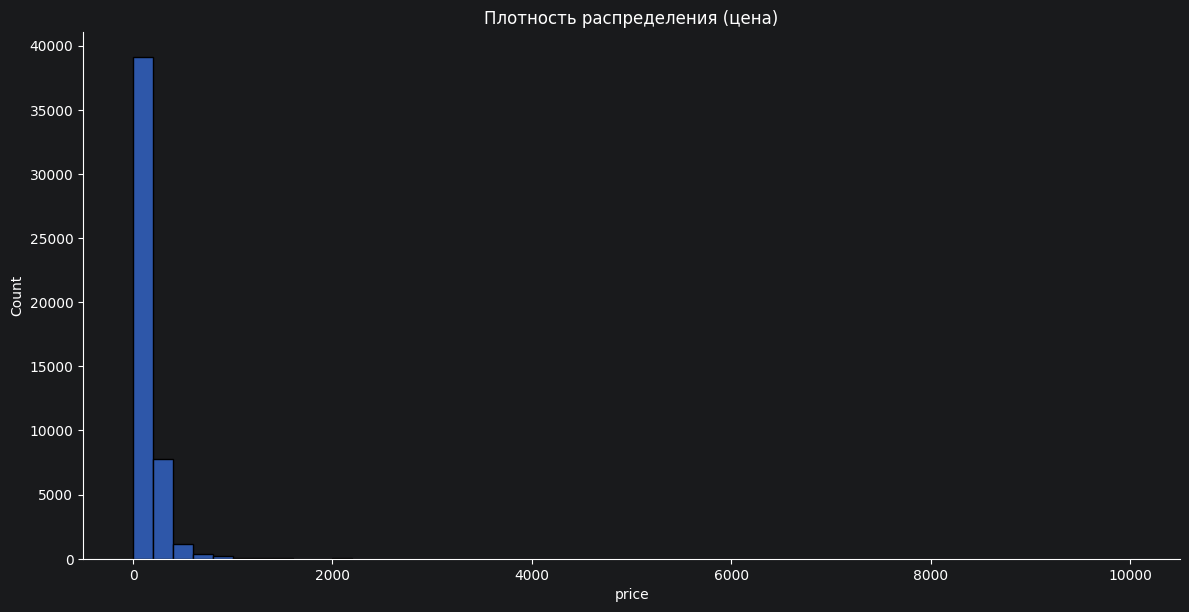

In [30]:
# график плотности распределения.
sns.displot(data=data, x="price", bins=50, height=6, aspect=2)
plt.title('Плотность распределения (цена)')
plt.show()
# Из этого графика можно понять что вл-во строк с ценой от 1000 ничтожно мало и они для нас являются выбросами которые не стоит принимать во внимание. Эти строки необходимо удалить из датасета


In [31]:
# Замена аномалий. Выкидываем черезвычайно высокие цены
data_clean = data_clean.drop(data_clean[data_clean['price'] > 1000].index)


In [34]:
# предобработка
# числовые масштабируем StandardScaler
# текстовые цифруем OneHotEncoder
# заменяем пустые на ноль

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Формирование X и y
X = data_clean.drop(['price'], axis=1)
y = data_clean['price']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# цифровые поля для масштабирования
num_features = ['minimum_nights', 'number_of_reviews',
                    'calculated_host_listings_count', 'availability_365',
                   'distance_to_manhattan']
# категоральные поля для преобразования в число
cat_features = ['neighbourhood_group', 'room_type','neighbourhood']

# создаем пайплайн
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

In [35]:
# Создание пайплайнов для разных моделей, для обучения в цикле
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, r2_score

# линейная регрессия
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Ваш ColumnTransformer
    ('regressor', LinearRegression())
])

# RidgeCV
model_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RidgeCV(
        alphas=[0.01, 0.1, 1.0, 10.0, 100.0],
        scoring='neg_mean_squared_error',
        cv=5
    ))
])
#LassoCV
model_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LassoCV(
        alphas=[0.001, 0.01, 0.1, 1.0, 10.0],
        cv=5,
        max_iter=10000,
        random_state=42
    ))
])
#ElasticNetCV
model_enet = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNetCV(
        alphas=[0.001, 0.01, 0.1, 1.0, 10.0],
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=5,
        max_iter=10000,
        random_state=42
    ))
])

models = {
    'Linear Regression': model_lr,
    'RidgeCV': model_ridge,
    'LassoCV': model_lasso,
    'ElasticNetCV': model_enet
}

# Обучение и оценка
results = {}

for name, model in models.items():
    print(f"Обучаю {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'R2': r2
    }

    print(f"{name}: MAE = {mae:.2f}, R² = {r2:.4f}\n")

Обучаю Linear Regression...
Linear Regression: MAE = 55.84, R² = 0.3482

Обучаю RidgeCV...
RidgeCV: MAE = 55.64, R² = 0.3494

Обучаю LassoCV...
LassoCV: MAE = 55.79, R² = 0.3483

Обучаю ElasticNetCV...
ElasticNetCV: MAE = 55.64, R² = 0.3494



Сравнение моделей:
                       MAE      R2
Linear Regression  55.8357  0.3482
RidgeCV            55.6415  0.3494
LassoCV            55.7924  0.3483
ElasticNetCV       55.6355  0.3494


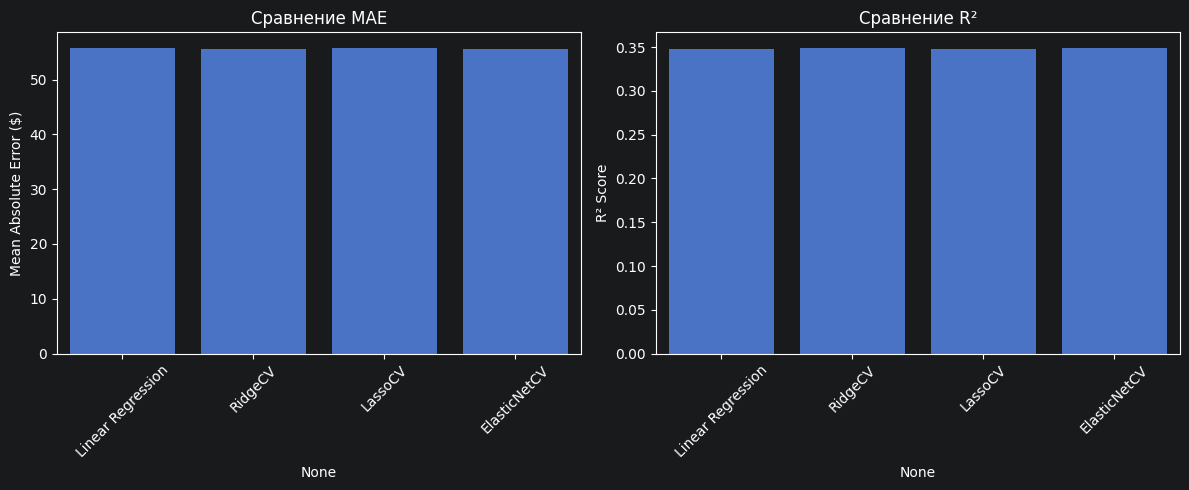

In [36]:
# сравнение каждого из методов на графике

import pandas as pd

# Сравнительная таблица
results_df = pd.DataFrame(results).T
print("Сравнение моделей:")
print(results_df.round(4))

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График MAE
sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[0])
axes[0].set_title('Сравнение MAE')
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].tick_params(axis='x', rotation=45)

# График R2
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[1])
axes[1].set_title('Сравнение R²')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Общиый вывод результаты почти одинаковые и точно к сожалению не высокая.


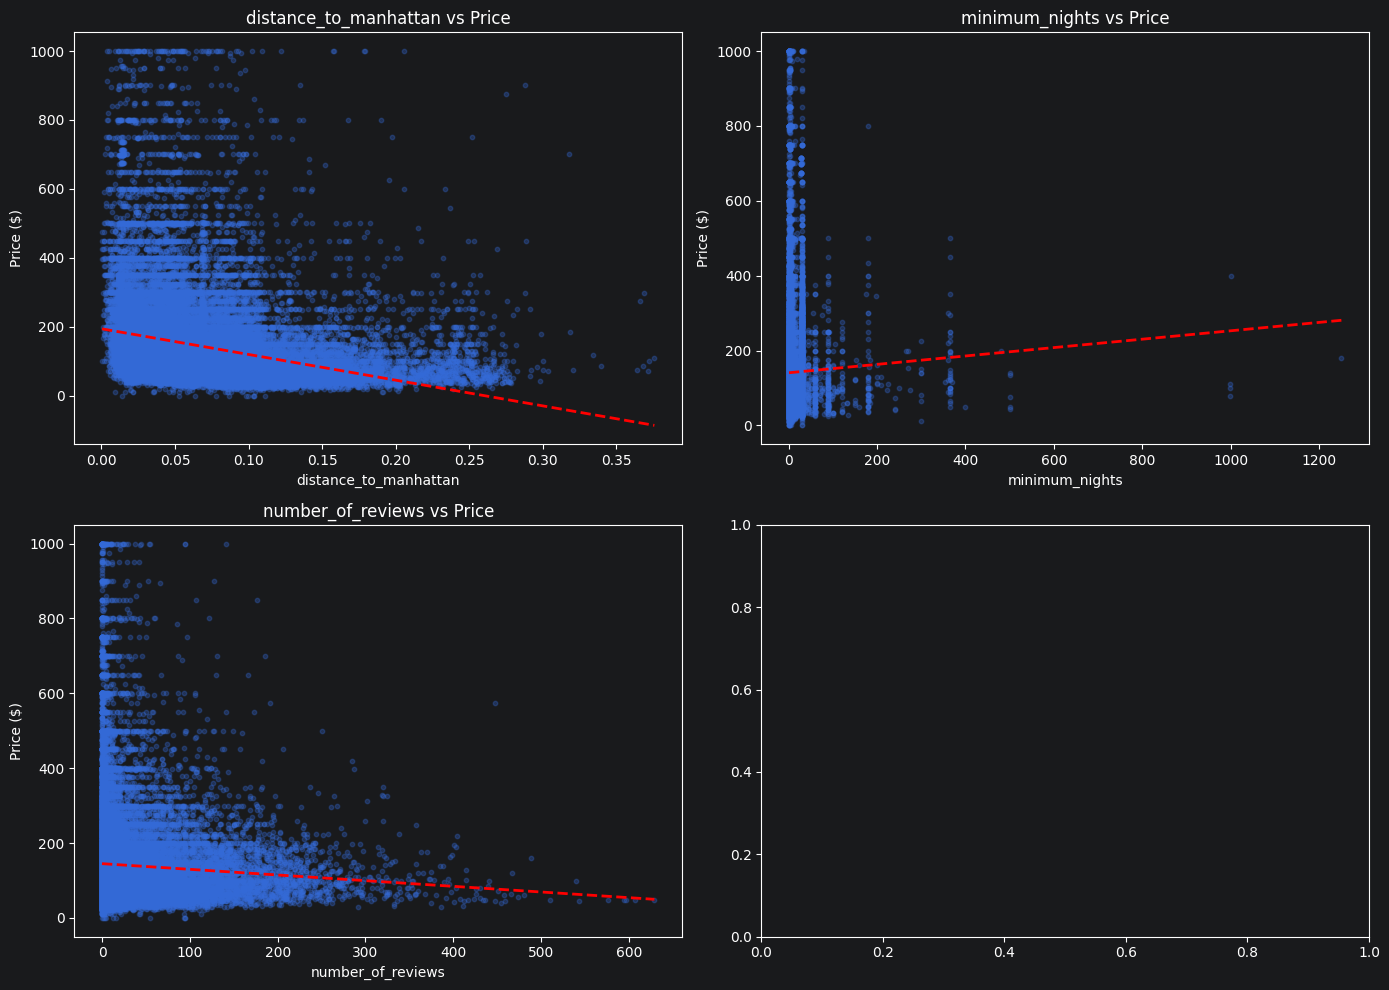

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Выбираем несколько признаков для визуализации
features_to_plot = ['distance_to_manhattan', 'minimum_nights', 'number_of_reviews']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features_to_plot):
    row, col = idx // 2, idx % 2
    axes[row, col].scatter(data_clean[feature], data_clean['price'], alpha=0.3, s=10)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Price ($)')
    axes[row, col].set_title(f'{feature} vs Price')

    # Добавляем линию линейной регрессии (красная)
    z = np.polyfit(data_clean[feature], data_clean['price'], 1)
    p = np.poly1d(z)
    axes[row, col].plot(data_clean[feature].sort_values(),
                         p(data_clean[feature].sort_values()),
                         "r--", linewidth=2)

plt.tight_layout()
plt.show()
# Вывод. Все взятые признаки по отношению к цене не имеют линейной зависимости


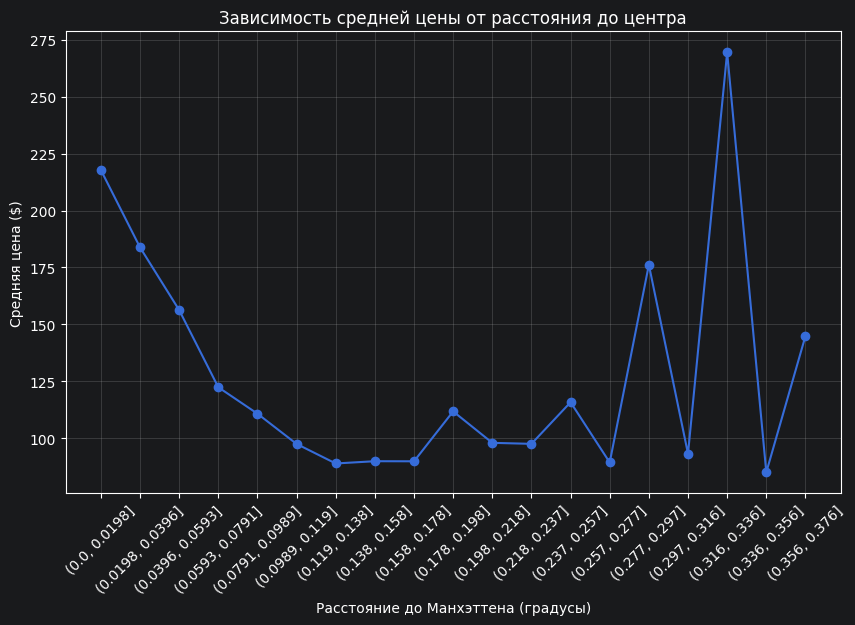

In [40]:
plt.figure(figsize=(10, 6))

# Разбиваем расстояние на интервалы
bins = np.linspace(0, data_clean['distance_to_manhattan'].max(), 20)
data_clean['dist_bins'] = pd.cut(data_clean['distance_to_manhattan'], bins)

# Средняя цена в каждом интервале
avg_price_by_dist = data_clean.groupby('dist_bins')['price'].mean()

plt.plot(avg_price_by_dist.index.astype(str), avg_price_by_dist.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel('Расстояние до Манхэттена (градусы)')
plt.ylabel('Средняя цена ($)')
plt.title('Зависимость средней цены от расстояния до центра')
plt.grid(True, alpha=0.3)
plt.show()
# Вывод : С начала чем дальше от центра тем дешевле но до определенного расстояния, дальше цена опять растет.